# Post-Preprocessing EDA
Four reliability checks before VAE training.

| # | Check | Must-see condition |
|---|---|---|
| 1 | **Scaling Validation** | mean ≈ 0, std ≈ 1 for every feature (train) |
| 2 | **Split Integrity** | train = 100 % normal · val & test ≈ natural default rate |
| 3 | **Sparsity / Cardinality** | input_dim ≤ 150; no pathologically sparse OHE group |
| 4 | **Val vs Test Distribution** | val and test anomaly rates must be within 1 pp of each other |

In [41]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from src.config import DATA_PROC_DIR

PROC = Path(DATA_PROC_DIR)

train_arr   = np.load(PROC / "train_features.npy")
val_arr     = np.load(PROC / "val_features.npy")
val_labels  = np.load(PROC / "val_labels.npy")
test_arr    = np.load(PROC / "test_features.npy")
test_labels = np.load(PROC / "test_labels.npy")

with open(PROC / "feature_columns.json") as f:
    feature_names: list[str] = json.load(f)

print(f"train_features : {train_arr.shape}  (normal only)")
print(f"val_features   : {val_arr.shape}   "
      f"normal: {(val_labels==0).sum():,}  anomaly: {(val_labels==1).sum():,}  "
      f"rate: {(val_labels==1).mean()*100:.1f} %")
print(f"test_features  : {test_arr.shape}  "
      f"normal: {(test_labels==0).sum():,}  anomaly: {(test_labels==1).sum():,}  "
      f"rate: {(test_labels==1).mean()*100:.1f} %")
print(f"feature_names  : {len(feature_names)} columns")

train_features : (753725, 53)  (normal only)
val_features   : (201797, 53)   normal: 161,513  anomaly: 40,284  rate: 20.0 %
test_features  : (201797, 53)  normal: 161,513  anomaly: 40,284  rate: 20.0 %
feature_names  : 53 columns


---
## Check 1 — Scaling Validation
StandardScaler fitted on train should produce **mean ≈ 0** and **std ≈ 1**  
for every feature in `train_features.npy`.  
Any feature with |mean| > 0.05 or |std − 1| > 0.05 is flagged.

In [42]:
MEAN_TOL = 0.05
STD_TOL  = 0.05

stats = pd.DataFrame(
    train_arr,
    columns=feature_names
).describe().T[["mean", "std", "min", "max"]]

stats["mean_flag"] = stats["mean"].abs() > MEAN_TOL
stats["std_flag"]  = (stats["std"] - 1).abs() > STD_TOL
stats["any_flag"]  = stats["mean_flag"] | stats["std_flag"]

flagged = stats[stats["any_flag"]]
ok      = stats[~stats["any_flag"]]

print(f"PASS: {len(ok)} features within tolerance")
print(f"FLAG: {len(flagged)} features outside tolerance")
if not flagged.empty:
    print("\n--- Flagged features ---")
    print(flagged[["mean", "std", "min", "max"]].to_string())
else:
    print("\n✓ All features correctly scaled.")

PASS: 53 features within tolerance
FLAG: 0 features outside tolerance

✓ All features correctly scaled.


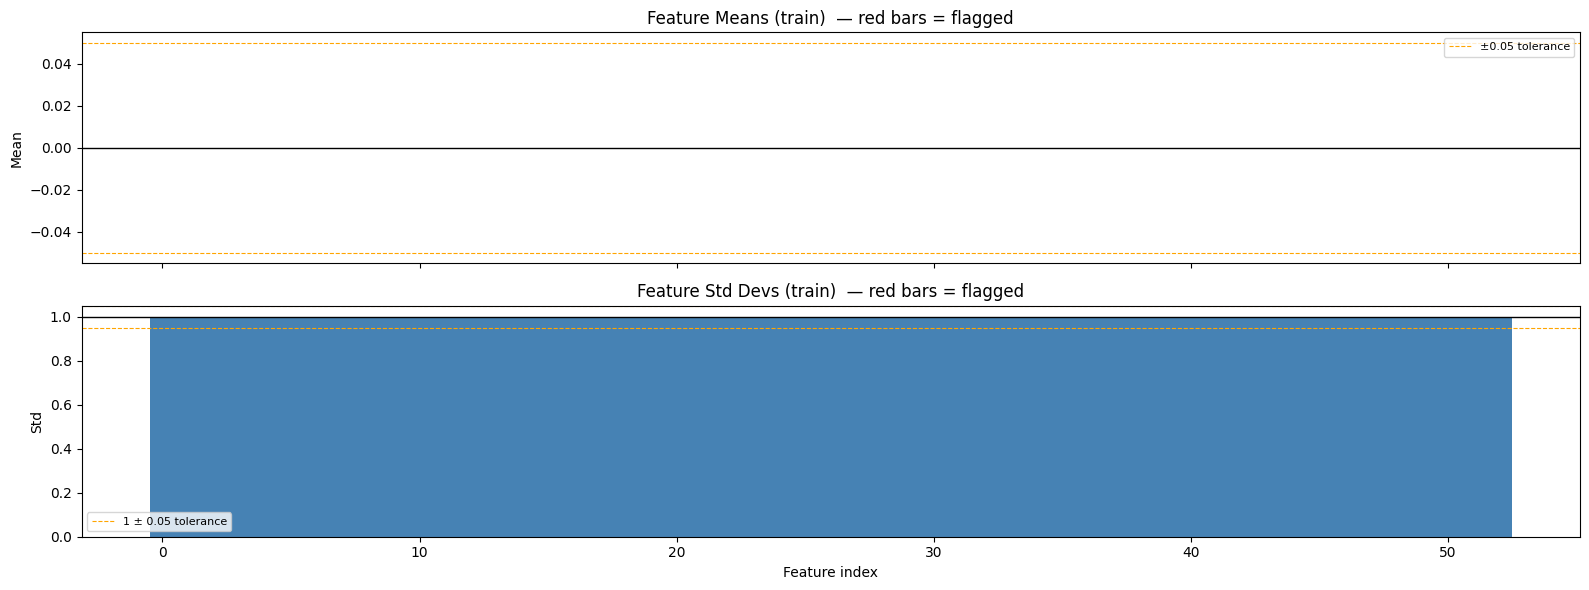

In [43]:
# Visual: mean and std across all features
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

x = range(len(feature_names))

axes[0].bar(x, stats["mean"], color=np.where(stats["mean_flag"], "crimson", "steelblue"), width=1)
axes[0].axhline(0,  color="black", linewidth=1)
axes[0].axhline( MEAN_TOL, color="orange", linewidth=0.8, linestyle="--", label=f"±{MEAN_TOL} tolerance")
axes[0].axhline(-MEAN_TOL, color="orange", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("Mean")
axes[0].set_title("Feature Means (train)  — red bars = flagged")
axes[0].legend(fontsize=8)

axes[1].bar(x, stats["std"], color=np.where(stats["std_flag"], "crimson", "steelblue"), width=1)
axes[1].axhline(1, color="black", linewidth=1)
axes[1].axhline(1 + STD_TOL, color="orange", linewidth=0.8, linestyle="--", label=f"1 ± {STD_TOL} tolerance")
axes[1].axhline(1 - STD_TOL, color="orange", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("Std")
axes[1].set_title("Feature Std Devs (train)  — red bars = flagged")
axes[1].set_xlabel("Feature index")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../reports/figures/check1_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

In [44]:
# Full .describe() table (all features)
pd.set_option("display.max_rows", 200)
stats[["mean", "std", "min", "max", "any_flag"]]

,mean,std,min,max,any_flag
loan_amnt,-5.057077e-08,1.000001,-1.574225,2.984921,False
funded_amnt,-4.026632e-08,1.000001,-1.574008,2.987315,False
term,-1.449304e-07,1.000001,-0.506081,1.975967,False
int_rate,-3.965899e-08,1.000001,-1.616001,4.058960,False
installment,3.850505e-08,1.000001,-1.636816,4.944870,False
grade,-6.214051e-08,1.000001,-1.281183,3.595504,False
sub_grade,-7.601812e-09,1.000001,-1.602986,3.941245,False
emp_length,5.000393e-08,1.000001,-1.668969,1.116196,False
annual_inc,1.763296e-08,1.000001,-1.063489,149.413559,False
dti,5.330378e-08,1.000001,-1.701582,88.722008,False


---
## Check 2 — Split Integrity
Three things must hold:
1. **Train is normal-only** — no Charged Off rows (VAE semi-supervised constraint).
2. **Val & test anomaly rates match the natural portfolio default rate** (~20 %).
3. **Val and test are mutually exclusive** — no Charged Off row appears in both.

We verify (1) and (2) arithmetically from array shapes and labels.
We verify (3) by confirming total anomaly rows ≤ total Charged Off in the dataset
(zero-overlap guarantee is enforced by the sequential sampling in `preprocess.py`).

In [45]:
TRAIN_NORMAL_FRAC = 0.70   # must match src/preprocess.py
VAL_NORMAL_FRAC   = 0.15
FRAC_TOL          = 0.005  # 0.5 pp rounding tolerance
RATE_TOL          = 0.02   # val vs test anomaly rate must match within 2 pp

n_train        = train_arr.shape[0]
n_val_normal   = int((val_labels  == 0).sum())
n_val_anomaly  = int((val_labels  == 1).sum())
n_test_normal  = int((test_labels == 0).sum())
n_test_anomaly = int((test_labels == 1).sum())

# Reconstruct total normal count: train + val_normal + test_normal
n_total_normal = n_train + n_val_normal + n_test_normal

actual_train_frac = n_train      / n_total_normal
actual_val_frac   = n_val_normal / n_total_normal
actual_test_frac  = n_test_normal/ n_total_normal

val_anomaly_rate  = n_val_anomaly  / (n_val_normal  + n_val_anomaly)
test_anomaly_rate = n_test_anomaly / (n_test_normal + n_test_anomaly)

print("=== Split Integrity ===")
print(f"  Total Fully Paid reconstructed : {n_total_normal:>10,}")
print(f"  train  (normal only)           : {n_train:>10,}  "
      f"({actual_train_frac*100:.1f} % of normal, target {TRAIN_NORMAL_FRAC*100:.0f} %)")
print(f"  val    normal + anomaly        : {n_val_normal:>10,} + {n_val_anomaly:,}  "
      f"({actual_val_frac*100:.1f} % of normal, target {VAL_NORMAL_FRAC*100:.0f} %)")
print(f"  test   normal + anomaly        : {n_test_normal:>10,} + {n_test_anomaly:,}  "
      f"({actual_test_frac*100:.1f} % of normal, target {(1-TRAIN_NORMAL_FRAC-VAL_NORMAL_FRAC)*100:.0f} %)")
print()
print(f"  val  anomaly rate : {val_anomaly_rate*100:.2f} %")
print(f"  test anomaly rate : {test_anomaly_rate*100:.2f} %")
print(f"  |val - test| rate : {abs(val_anomaly_rate - test_anomaly_rate)*100:.2f} pp  "
      f"(tolerance {RATE_TOL*100:.0f} pp)")
print()

train_frac_ok = abs(actual_train_frac - TRAIN_NORMAL_FRAC) < FRAC_TOL
val_frac_ok   = abs(actual_val_frac   - VAL_NORMAL_FRAC)   < FRAC_TOL
test_frac_ok  = abs(actual_test_frac  - (1 - TRAIN_NORMAL_FRAC - VAL_NORMAL_FRAC)) < FRAC_TOL
rates_match   = abs(val_anomaly_rate  - test_anomaly_rate) < RATE_TOL
frac_ok       = train_frac_ok and val_frac_ok and test_frac_ok

for label, passed, detail in [
    ("Train fraction (70 %)",      train_frac_ok, f"{actual_train_frac*100:.2f} %"),
    ("Val   fraction (15 %)",      val_frac_ok,   f"{actual_val_frac*100:.2f} %"),
    ("Test  fraction (15 %)",      test_frac_ok,  f"{actual_test_frac*100:.2f} %"),
    ("Val/test anomaly rates match",rates_match,  
     f"val={val_anomaly_rate*100:.2f} %  test={test_anomaly_rate*100:.2f} %"),
]:
    icon = '✓' if passed else '✗'
    print(f"  {icon}  {label:<35} {detail}")

=== Split Integrity ===
  Total Fully Paid reconstructed :  1,076,751
  train  (normal only)           :    753,725  (70.0 % of normal, target 70 %)
  val    normal + anomaly        :    161,513 + 40,284  (15.0 % of normal, target 15 %)
  test   normal + anomaly        :    161,513 + 40,284  (15.0 % of normal, target 15 %)

  val  anomaly rate : 19.96 %
  test anomaly rate : 19.96 %
  |val - test| rate : 0.00 pp  (tolerance 2 pp)

  ✓  Train fraction (70 %)               70.00 %
  ✓  Val   fraction (15 %)               15.00 %
  ✓  Test  fraction (15 %)               15.00 %
  ✓  Val/test anomaly rates match        val=19.96 %  test=19.96 %


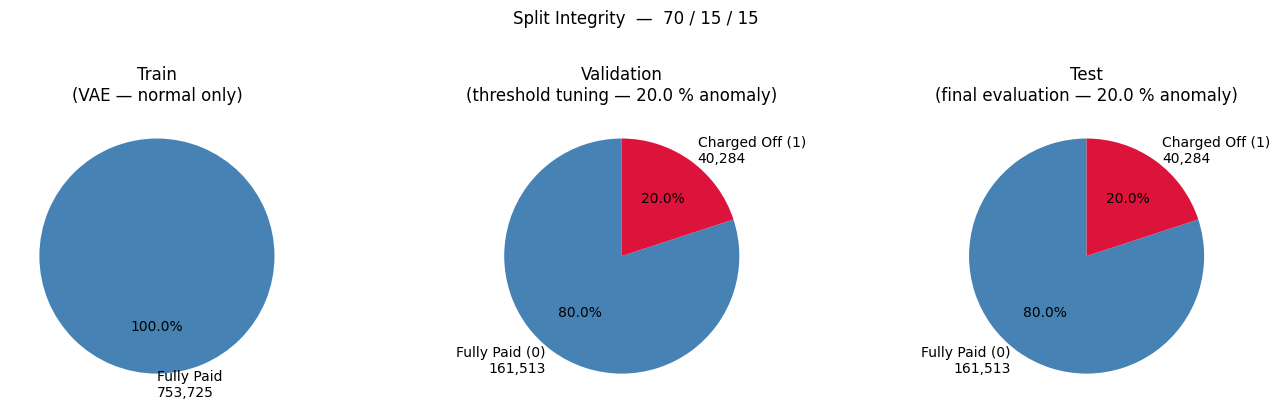

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Train — 100 % normal
axes[0].pie(
    [n_train],
    labels=[f"Fully Paid\n{n_train:,}"],
    colors=["steelblue"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title("Train\n(VAE — normal only)")

# Val — mixed, natural rate
axes[1].pie(
    [n_val_normal, n_val_anomaly],
    labels=[f"Fully Paid (0)\n{n_val_normal:,}",
            f"Charged Off (1)\n{n_val_anomaly:,}"],
    colors=["steelblue", "crimson"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title(f"Validation\n(threshold tuning — {val_anomaly_rate*100:.1f} % anomaly)")

# Test — mixed, natural rate
axes[2].pie(
    [n_test_normal, n_test_anomaly],
    labels=[f"Fully Paid (0)\n{n_test_normal:,}",
            f"Charged Off (1)\n{n_test_anomaly:,}"],
    colors=["steelblue", "crimson"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[2].set_title(f"Test\n(final evaluation — {test_anomaly_rate*100:.1f} % anomaly)")

plt.suptitle("Split Integrity  —  70 / 15 / 15", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/check2_split_integrity.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Check 3 — Sparsity & Cardinality (OHE)
OHE expands the feature space. We check:
- Total `input_dim` — must be ≤ 150 to avoid overfitting / sparse overcrowding
- Per-group column count — flag any OHE group with > 30 categories
- Mean activation per OHE group — near-zero means almost always inactive (dead column)

In [47]:
INPUT_DIM_WARN  = 150   # warn if wider than this
GROUP_CAT_WARN  = 30    # warn if a single OHE group has more dummies than this
DEAD_COL_THRESH = 0.01  # flag OHE columns whose mean activation < 1 %

input_dim = train_arr.shape[1]
print(f"input_dim : {input_dim}")
if input_dim > INPUT_DIM_WARN:
    print(f"  ⚠ WARNING — input_dim {input_dim} > {INPUT_DIM_WARN}. "
          "Consider collapsing high-cardinality OHE groups.")
else:
    print(f"  ✓ input_dim within acceptable range.")
print()

# --- Identify OHE groups from feature_names (format: 'base_category') ---
NOMINAL_BASES = [
    "home_ownership", "verification_status", "purpose",
    "addr_state", "initial_list_status", "application_type",
]

# sklearn OHE produces names like "home_ownership_MORTGAGE"
ohe_groups: dict[str, list[int]] = {base: [] for base in NOMINAL_BASES}
numeric_indices: list[int] = []

for idx, name in enumerate(feature_names):
    matched = False
    for base in NOMINAL_BASES:
        if name.startswith(base + "_") or name == base:
            ohe_groups[base].append(idx)
            matched = True
            break
    if not matched:
        numeric_indices.append(idx)

print(f"Numeric / ordinal features : {len(numeric_indices)}")
print()
print("OHE group cardinality:")
for base, indices in ohe_groups.items():
    n_cats = len(indices)
    flag = "  HIGH CARDINALITY" if n_cats > GROUP_CAT_WARN else ""
    # Mean activation (after StandardScaler — un-scale to get original 0/1 mean)
    if indices:
        raw_means = train_arr[:, indices].mean(axis=0)   # scaled values
        # approximate unscaled mean: scaler shifts 0/1 binary to negative, so
        # we report the scaled mean directly — near 0 means ~50 % active,
        # very negative means rarely active (before scaling the mean was ~0)
        min_mean = raw_means.min()
        max_mean = raw_means.max()
    else:
        min_mean = max_mean = float('nan')
    print(f"  {base:<26}: {n_cats:>3} dummies | scaled mean range [{min_mean:+.3f}, {max_mean:+.3f}]{flag}")

input_dim : 53
  ✓ input_dim within acceptable range.

Numeric / ordinal features : 19

OHE group cardinality:
  home_ownership            :   3 dummies | scaled mean range [-0.000, -0.000]
  verification_status       :   3 dummies | scaled mean range [-0.000, -0.000]
  purpose                   :   8 dummies | scaled mean range [-0.000, +0.000]
  addr_state                :  16 dummies | scaled mean range [-0.000, +0.000]
  initial_list_status       :   2 dummies | scaled mean range [-0.000, +0.000]
  application_type          :   2 dummies | scaled mean range [-0.000, -0.000]


In [48]:
# Dead-column detection: OHE columns that are almost never active
# We load ohe_encoder.pkl to get the original 0/1 activations before scaling
import pickle

with open(PROC / "ohe_encoder.pkl", "rb") as f:
    ohe_enc = pickle.load(f)
with open(PROC / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Unscale train_arr to recover original (imputed + OHE) values
train_unscaled = scaler.inverse_transform(train_arr)

dead_cols = []
for base, indices in ohe_groups.items():
    for idx in indices:
        col_mean = train_unscaled[:, idx].mean()
        if col_mean < DEAD_COL_THRESH:
            dead_cols.append((feature_names[idx], col_mean))

print(f"Dead OHE columns (mean activation < {DEAD_COL_THRESH*100:.0f} %): {len(dead_cols)}")
if dead_cols:
    dead_df = pd.DataFrame(dead_cols, columns=["feature", "mean_activation"])
    dead_df = dead_df.sort_values("mean_activation")
    print(dead_df.to_string(index=False))
    print()
    if len(dead_cols) > 10:
        print("  ⚠ Many dead columns detected. Consider collapsing rare categories "
              "into an 'OTHER' bucket in preprocess.py before training.")
else:
    print("  ✓ No dead columns detected.")

Dead OHE columns (mean activation < 1 %): 0
  ✓ No dead columns detected.


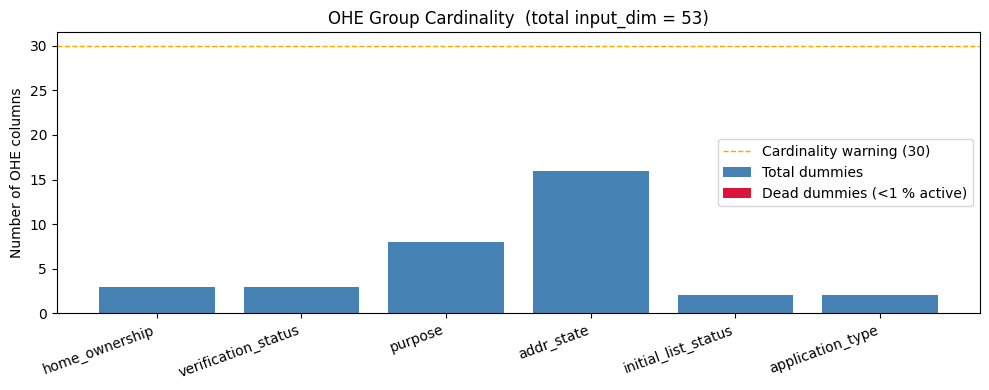

In [49]:
# Visual: OHE group sizes + sparsity bar chart
group_names  = list(ohe_groups.keys())
group_sizes  = [len(v) for v in ohe_groups.values()]

# Mean sparsity per group (fraction of columns that are dead)
dead_set = {name for name, _ in dead_cols}
group_dead = [
    sum(1 for idx in indices if feature_names[idx] in dead_set)
    for indices in ohe_groups.values()
]

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(group_names))
bars_total = ax.bar(x, group_sizes, label="Total dummies", color="steelblue")
bars_dead  = ax.bar(x, group_dead,  label="Dead dummies (<1 % active)", color="crimson")
ax.axhline(GROUP_CAT_WARN, color="orange", linestyle="--", linewidth=1,
           label=f"Cardinality warning ({GROUP_CAT_WARN})")
ax.set_xticks(list(x))
ax.set_xticklabels(group_names, rotation=20, ha="right")
ax.set_ylabel("Number of OHE columns")
ax.set_title(f"OHE Group Cardinality  (total input_dim = {input_dim})")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/check3_sparsity.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Summary
Run the cell below to get a consolidated pass/fail report.

In [50]:
n_flagged_scaling = int(stats["any_flag"].sum())
n_high_card       = sum(1 for s in group_sizes if s > GROUP_CAT_WARN)

checks = [
    ("Scaling Validation",
     n_flagged_scaling == 0,
     f"{n_flagged_scaling} feature(s) outside mean≈0 / std≈1 tolerance"),

    ("Train is normal-only (70 %)",
     train_frac_ok,
     f"train fraction = {actual_train_frac*100:.2f} %  (target 70 %)"),

    ("Val fraction ≈ 15 % of normal",
     val_frac_ok,
     f"val fraction = {actual_val_frac*100:.2f} %  (target 15 %)"),

    ("Test fraction ≈ 15 % of normal",
     test_frac_ok,
     f"test fraction = {actual_test_frac*100:.2f} %  (target 15 %)"),

    ("Val / test anomaly rates match",
     rates_match,
     f"val={val_anomaly_rate*100:.2f} %  test={test_anomaly_rate*100:.2f} %  "
     f"diff={abs(val_anomaly_rate-test_anomaly_rate)*100:.2f} pp"),

    ("input_dim ≤ 150",
     input_dim <= INPUT_DIM_WARN,
     f"input_dim = {input_dim}"),

    ("No high-cardinality OHE group",
     n_high_card == 0,
     f"{n_high_card} group(s) with >{GROUP_CAT_WARN} dummies"),

    ("No dead OHE columns",
     len(dead_cols) == 0,
     f"{len(dead_cols)} dead column(s) found"),
]

print("=" * 62)
print("POST-PREP EDA — SUMMARY")
print("=" * 62)
all_pass = True
for name, passed, detail in checks:
    icon = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {icon}  {name}")
    print(f"         {detail}")
    if not passed:
        all_pass = False
print("=" * 62)
if all_pass:
    print("  All checks passed — safe to proceed to VAE training.")
else:
    print("  One or more checks FAILED — review preprocess.py before training.")
print("=" * 62)

POST-PREP EDA — SUMMARY
  ✓ PASS  Scaling Validation
         0 feature(s) outside mean≈0 / std≈1 tolerance
  ✓ PASS  Train is normal-only (70 %)
         train fraction = 70.00 %  (target 70 %)
  ✓ PASS  Val fraction ≈ 15 % of normal
         val fraction = 15.00 %  (target 15 %)
  ✓ PASS  Test fraction ≈ 15 % of normal
         test fraction = 15.00 %  (target 15 %)
  ✓ PASS  Val / test anomaly rates match
         val=19.96 %  test=19.96 %  diff=0.00 pp
  ✓ PASS  input_dim ≤ 150
         input_dim = 53
  ✓ PASS  No high-cardinality OHE group
         0 group(s) with >30 dummies
  ✓ PASS  No dead OHE columns
         0 dead column(s) found
  All checks passed — safe to proceed to VAE training.
